# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Sinadjan, Joseph Daniel
- _Student No._: 2024-13266
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->
### Report discussion

#### Particle in a Harmonic Oscillator Potential

The quantum harmonic oscillator is a familiar object to many a student of physics. It appears in real world problems while being well behaved enough where the analytic solution can be reasonably derived. Here, we take a numerical approach to the solution.

#### Mathematical Basis

States live in a Hilbert space, which is a space of infinite-dimensional 'vectors'. Operators act on states, mapping them to other states in the space. Hermitian operator eigenvalues correspond to physical observables; their eigenvectors to eigenfunctions of the state. In a finite dimensional approximation states can be represented as a vector with components being some observable, and the operators as matrices. The corresponding matrix for the kinetic energy operator $\hat{T}$ is provided in the problem below, as well as that of the potential operator $\hat{U}$ for a harmonic oscillator:

$$V_i = \frac{1}{2} m \omega^2 {x_i}^2 $$

Our task is then to derive the eigenvalues and eigenstates of the Hamiltonian $\hat{H}$ in position representation.

#### Implementation

The Hamiltonian, an account of the total energy of a system, is simply the sum of kinetic and potential energy, or $\hat{T}+\hat{U}$ in operator parlance. A clever application of the central limit definition of the derivative and some linear algebra gives us the approximate form of $\hat{T}$ in finite dimensions: a banded matrix with $-2$'s in the diagonal and $1$'s in both adjacent off diagonals. For $\hat{V}$ the case is simpler still. In position representation it is a diagonal matrix where each nonzero entry $V_{ii}$ is simply the potential at position $x_i$. Most coding in this problem is simply a matter of applying these ideas to generate a matrix we can actually work with. Finally, running  <i>numpy.linalg.eigh</i>  on our Hamiltonian gives us our eigenvalues and eigenvectors.

#### Results

Plotting the first four eigenvectors, it is apparent that they are of the form of the analytical solutions. The plots taper off in the classically forbidden region, they alternate between odd and even, etc.
On the other hand, the eigenvalues are not so well behaved. (This is more relevant in the next section but I will discuss it here as it applies.) The numerically derived eigenvalues grow quadratically contrary to the (linear) analytical solution for the nth eigenenergy:

$$E = \hbar \omega \bigg( n+\frac{1}{2} \bigg) $$

This is a consequence of the fact that we are approximating our operators in finite dimensions. When we consider a larger area for our state to exist within, the numerical eigenvalues do approach the analytic value. In the implementation doing this corresponds to taking larger values for the *extent* variable.


#### Particle in a Combined Harmonic Oscillator and Electric Potential

Having experiece working with operators as matrices, states as vectors, etc. under our belt we can now proceed to a more general case. This time the particle is still subject to a harmonic oscillator potential, however it is now also affected by an electric potential.

#### Implementation

The bulk of the work we have done in the previous part remains however our potential vector now includes a linear electric potential component
at each position:

$$V_i = \frac{1}{2} m \omega^2 {x_i}^2 + qEx_i$$

where we take $qE = 1$. The exact same processes follow. Construct the Hamiltonian, take the eigenvalues and eigenvectors and plot interesting results.

#### Results

When plotted the potential now looks like a parabola shifted to the left. This makes sense; after all our potential of the form $ax^2+bx+c$ is always of some parabolic form. Our ground state wavefunction remains centered at the minimum of the potential. Our numerical eigenenergies also match the analytical values closely for small $n$, but diverge for larger values. Taking a larger *extent* again slows down the divergence between the two.

### Other comments
- No AI was used to write any of the code; however I did use Gemini Flash to help me debug. In particular, I used the LLM to provide a *correct* implementation of the linalg.eigh function which helped me identify an error in my own code: eigenvectors are not returned as a list-of-lists, but as a matrix where the nth *column* is the nth eigenvector. I was plotting rows when I should have been plotting columns.
- NONE of the writing is AI nor AI assisted nor AI proofread. I just thought now would be a good time to kill 2 birds with 1 stone (study 141 and 155)

  


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [2]:
import matplotlib.pyplot as plt
import numpy as np

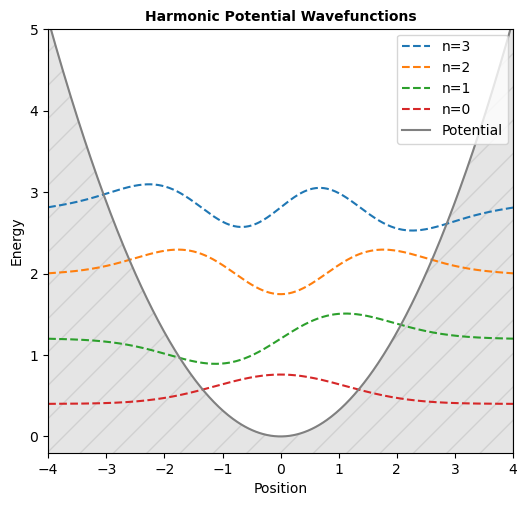

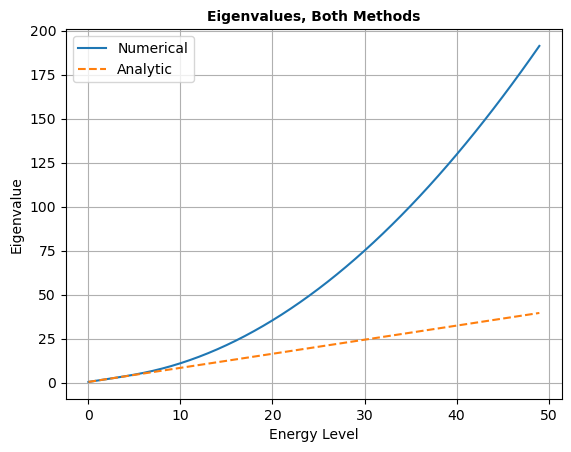

In [72]:
# code here

# relevant constants
extent = 8
dpoints = 500
mass = 1
w = 0.8
hbar = 1

# defining our input vectors
x_position = np.linspace(-0.5*extent, 0.5*extent, num = dpoints)

x_qho_pot = np.zeros(dpoints)
for i in range(dpoints):
    x_qho_pot[i] = 0.5*mass*(w**2)*(x_position[i]**2)


#hermitian function
def hermitian(x_position, x_qho_pot, hbar, mass):
    dim = x_position.shape[0]
    dx = x_position[1] - x_position[0]
    
    xs = np.eye(dim, dim, -1)
    ys = -2*np.eye(dim, dim, 0)
    zs = np.eye(dim, dim, 1)

    Ts = -(xs + ys + zs)*(hbar**2)/(2*mass*(dx**2))

    Vs = np.zeros((dim, dim))

    for i in range(dim):
        Vs[i,i] = x_qho_pot[i]

    Hs = Ts + Vs

    return Hs

#solve for eigenvalues, eigenvectors
evals, evecs = np.linalg.eigh(hermitian(x_position, x_qho_pot, hbar, mass))

#plotting eigenstates
fig, ax = plt.subplots(figsize=(6,5.5)
                      )


for i in reversed(range(4)):
    scaling = 4
    labels = ["n=0", "n=1", "n=2", "n=3"]
    ax.plot(x_position, evals[i] + scaling*(evecs[:,i]),
            label=labels[i],
            ls="--")
ax.plot(x_position, x_qho_pot, 
        label="Potential",
        color="gray")
ax.set_title("Harmonic Potential Wavefunctions",
             fontsize = 10,
             fontweight="bold")
ax.set_xlabel("Position")
ax.set_ylabel("Energy")
ax.set_ylim(-0.2,5)
ax.legend(loc=(0.75,0.73))
ax.margins(0)
ax.fill_between(x_position, x_qho_pot, -1,
               hatch="/",
               alpha=0.2,
               color="gray")

#plotting eigenvalues
fig2, ax2 = plt.subplots()
x_ax = np.array(range(50))

ax2.set_title("Eigenvalues, Both Methods",
             fontweight="bold",
             fontsize="10")
ax2.plot(x_ax, evals[:50], label="Numerical")
ax2.plot(x_ax, hbar*w*(x_ax + 0.5), \
         ls="--",
         label="Analytic")
ax2.set_xlabel("Energy Level")
ax2.set_ylabel("Eigenvalue")
ax2.legend()
ax2.grid()


#### Problem 1 code summary

Plotted wavefunctions are scaled up for visual clarity. I opted to input entries into the matrices and vectors using for loops. I know this is horrible memory-wise, but we havent cross that bridge yet so I'm sure (i think?) its okay for now. Also, plot styling still is the hardes part of this whole thing :P

---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

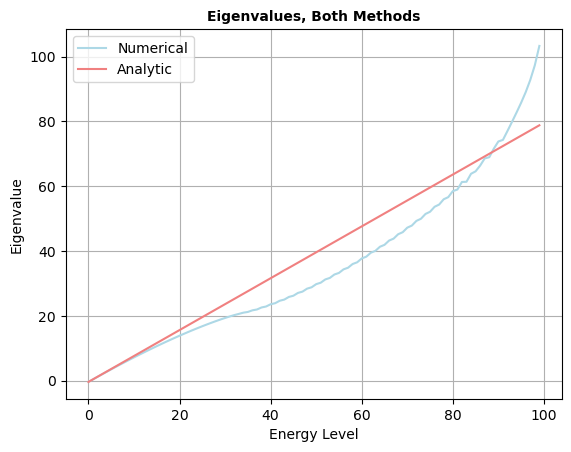

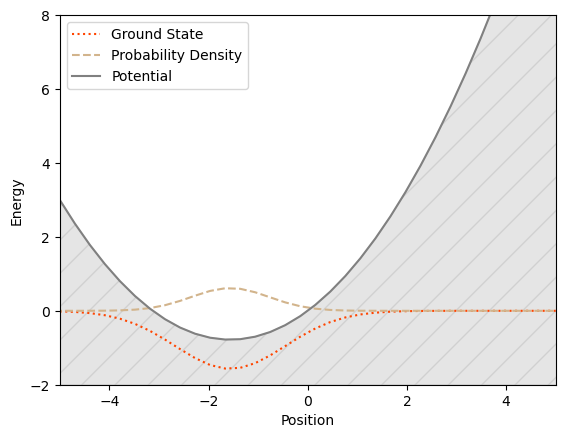

In [95]:
# code here

import matplotlib.pyplot as plt
import numpy as np


extent = 30
dpoints = 100

mass = 1
w = 0.8
hbar = 1

x_position = np.linspace(-0.5*extent, 0.5*extent, num = dpoints)

x_electric_pot = np.zeros(dpoints)
for i in range(dpoints):
    x_electric_pot[i] = 0.5*mass*(w**2)*(x_position[i]**2) + x_position[i]

def hermitian(x_position, x_qho_pot, hbar, mass):
    dim = x_position.shape[0]
    dx = x_position[1] - x_position[0]
    
    xs = np.eye(dim, dim, -1)
    ys = -2*np.eye(dim, dim, 0)
    zs = np.eye(dim, dim, 1)

    Ts = -(xs + ys + zs)*(hbar**2)/(2*mass*(dx**2))

    Vs = np.zeros((dim, dim))

    for i in range(dim):
        Vs[i,i] = x_qho_pot[i]

    Hs = Ts + Vs

    return Hs

evals, evecsn = np.linalg.eigh(hermitian(x_position, x_electric_pot, hbar, mass))




fig, ax= plt.subplots()

x_ax = np.array(range(100))
theoretical = hbar*w*(x_ax + 0.5) - 1/(2*mass*w**2)

ax.plot(x_ax, evals[:100], 
        label="Numerical",
        color="lightblue")
ax.plot(x_ax, theoretical, 
        label="Analytic",
        color="lightcoral")
ax.set_title("Eigenvalues, Both Methods",
             fontweight="bold",
             fontsize="10")
ax.set_xlabel("Energy Level")
ax.set_ylabel("Eigenvalue")
ax.grid()
ax.legend()

fig2, ax2 = plt.subplots()

ax2.plot(x_position, 4*evecsn[:,0],
         ls=":",
         color="orangered",
         label="Ground State")
ax2.plot(x_position, 4*evecsn[:,0]**2,
         ls="--",
         color="tan",
         label="Probability Density")
ax2.plot(x_position, x_electric_pot,
         color="gray",
         label="Potential")
ax2.set_xlim(-5,5)
ax2.set_ylim(-2,8)
ax2.fill_between(x_position, x_electric_pot, -2,
                hatch="/",
                color="gray",
                alpha=0.2)
ax2.set_xlabel("Position")
ax2.set_ylabel("Energy")
ax2.legend()

#### Problem 2 code summary

Mostly the same as problem 1, not much to say. It is noteworthy that the potential here goes below zero, but since negative potentials arent that big of a deal it doesnt have much effect on the physics of the scenario itself.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)